# EfficientFormerV2-S0 + TSM-S3 + FrameMean — Held-Out Evaluation Only
## RWF-2000 + UCF-Crime Fighting + Bus Violence

Notebook ini **tidak melakukan training**. Ia memuat `best.pt` dari eksperimen `efv2_tsm_s3_frame_mean`, merekonstruksi arsitektur yang sama persis dengan notebook training E1, lalu mengevaluasi tiga held-out domain secara terpisah.

Untuk seed berikutnya, ubah **hanya** `RUN_SEED = 0` menjadi `42` atau `123`.

In [1]:
# Jalankan sekali pada awal sesi Google Colab.
!pip -q install timm

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import json
import random
import platform
import warnings
import shutil
from contextlib import nullcontext
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from timm import create_model
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

print("Python :", platform.python_version())
print("PyTorch:", torch.__version__)
print("timm   :", timm.__version__)
print("CUDA   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


Python : 3.13.15
PyTorch: 2.11.0+cu128
timm   : 1.0.28
CUDA   : True
GPU    : NVIDIA A100-SXM4-40GB


## 1. Konfigurasi seed, checkpoint, dan held-out datasets

In [4]:
# ============================================================
# SATU-SATUNYA VARIABEL YANG DIUBAH ANTAR-SEED
# ============================================================
RUN_SEED = 0   # <-- ubah hanya menjadi 0 / 42 / 123

if RUN_SEED not in (0, 42, 123):
    raise ValueError(
        f"RUN_SEED harus salah satu dari (0, 42, 123), mendapat {RUN_SEED}."
    )

# ============================================================
# MODEL / CHECKPOINT
# ============================================================
MODEL_ROOT = Path(
    "/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet"
)

VARIANT = "efv2_tsm_s3_frame_mean"

# Konfigurasi arsitektur HARUS identik dengan notebook training E1.
SEQUENCE_LENGTH = 16
RAW_HEIGHT = 64
RAW_WIDTH = 64
BACKBONE_INPUT_SIZE = 224
NUM_CLASSES = 2
CLASS_NAMES = ["NonViolence", "Violence"]

TSM_SHIFT_DIV = 8
TSM_AFTER_STAGE_INDICES = (2,)   # Python index 2 = setelah human Stage 3
TSM_PLACEMENT_NAME = "after_stage3_before_stage4"

# Kandidat folder mengikuti pola training E1 yang pernah dipakai.
# Resolver juga mempunyai fallback recursive search yang aman.
CHECKPOINT_ROOT_CANDIDATES = [
    MODEL_ROOT / "EffTempNet_EFv2TSM_S3_FrameMean_NoLS_Seed0_v1",
    MODEL_ROOT / f"EffTempNet_EFv2TSM_S3_FrameMean_NoLS_Seed{RUN_SEED}_v1",
    MODEL_ROOT / f"EffTempNet_EFv2TSM_S3_FrameMean_NoLS_seed{RUN_SEED}_v1",
    MODEL_ROOT / f"EffTempNet_EFv2TSM_S3_FrameMean_NoLS_{RUN_SEED}Seeds_v1",
]

# Optional manual override. Biarkan None kecuali resolver menemukan 0 atau >1 checkpoint.
CHECKPOINT_PATH_OVERRIDE = None

def resolve_checkpoint(seed: int) -> Path:
    if CHECKPOINT_PATH_OVERRIDE is not None:
        path = Path(CHECKPOINT_PATH_OVERRIDE)
        if not path.exists():
            raise FileNotFoundError(
                f"CHECKPOINT_PATH_OVERRIDE tidak ditemukan: {path}"
            )
        return path

    direct_matches = []
    for root in CHECKPOINT_ROOT_CANDIDATES:
        candidate = root / VARIANT / f"seed_{seed}" / "best.pt"
        if candidate.exists():
            direct_matches.append(candidate)

    direct_matches = list(dict.fromkeys(direct_matches))

    if len(direct_matches) == 1:
        return direct_matches[0]

    if len(direct_matches) > 1:
        raise RuntimeError(
            "Ditemukan lebih dari satu candidate best.pt. "
            "Set CHECKPOINT_PATH_OVERRIDE secara eksplisit:\n"
            + "\n".join(str(p) for p in direct_matches)
        )

    # Fallback: hanya mencari path dengan variant dan seed yang tepat.
    recursive_matches = sorted(
        MODEL_ROOT.glob(f"**/{VARIANT}/seed_{seed}/best.pt")
    )

    if len(recursive_matches) == 1:
        return recursive_matches[0]

    if len(recursive_matches) == 0:
        raise FileNotFoundError(
            f"best.pt {VARIANT} seed {seed} tidak ditemukan di {MODEL_ROOT}.\n"
            "Pastikan checkpoint tersimpan atau isi CHECKPOINT_PATH_OVERRIDE."
        )

    raise RuntimeError(
        f"Ditemukan {len(recursive_matches)} checkpoint untuk {VARIANT} seed {seed}. "
        "Agar tidak salah checkpoint, isi CHECKPOINT_PATH_OVERRIDE:\n"
        + "\n".join(str(p) for p in recursive_matches)
    )

CHECKPOINT_PATH = resolve_checkpoint(RUN_SEED)

EVAL_OUTPUT_DIR = (
    MODEL_ROOT
    / "HeldOut_Evaluation"
    / "EFv2_TSM_S3_FrameMean"
    / f"seed_{RUN_SEED}"
)

# ============================================================
# HELD-OUT DATASET
# ============================================================
BENCHMARK_ROOT = Path(
    "/content/drive/MyDrive/IVS/ViolenceDataset/Benchmark"
)

# RWF memakai cache lama yang sama dengan eksperimen E1 jika tersedia.
EXISTING_CACHE_DIR = MODEL_ROOT / "new_saved_dataset"

# UCF dan BV menggunakan shared cache yang sama dengan evaluator held-out lain.
HELDOUT_CACHE_DIR = MODEL_ROOT / "heldout_cache_rgb64_v2"

HELDOUT_SPECS = {
    "RWF": {
        "raw_dir": BENCHMARK_ROOT / "RWF",
        "cache_name": "RWF",
        "cache_dir": EXISTING_CACHE_DIR,
        "nonviolence_dir": None,
        "violence_dir": None,
    },
    "UCF": {
        "raw_dir": BENCHMARK_ROOT / "UCF",
        "cache_name": "UCF",
        "cache_dir": HELDOUT_CACHE_DIR,
        "nonviolence_dir": None,
        "violence_dir": None,
    },
    "BV": {
        "raw_dir": BENCHMARK_ROOT / "BV",
        "cache_name": "BV",
        "cache_dir": HELDOUT_CACHE_DIR,
        "nonviolence_dir": None,
        "violence_dir": None,
    },
}

NONVIOLENCE_ALIASES = (
    "NonViolence", "Non-Violence", "Non_Violence",
    "Nonviolent", "NonViolent",
    "NonFight", "Non-Fight", "Non_Fight",
    "Normal", "NormalVideos", "Normal_Videos",
)

VIOLENCE_ALIASES = (
    "Violence", "Violent", "Fight", "Fighting",
    "FightVideos", "ViolentVideos", "Abnormal",
)

# ============================================================
# PREPROCESSING — IDENTIK DENGAN TRAINING E1
# ============================================================
PREFER_LEGACY_CACHE = True
LEGACY_CACHE_COLOR_ORDER = "BGR"
AUTO_SCALE_LEGACY_CACHE = True

# Evaluation only. Tidak ada optimizer, scheduler, backward, atau update bobot.
EVAL_BATCH_SIZE = 4
NUM_WORKERS = 2
USE_AMP = False
BOOTSTRAP_SAMPLES = 1000
BOOTSTRAP_SEED = 2026
ALLOW_BUILD_CACHE = True

EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HELDOUT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_SEED        :", RUN_SEED)
print("VARIANT         :", VARIANT)
print("CHECKPOINT_PATH :", CHECKPOINT_PATH)
print("OUTPUT          :", EVAL_OUTPUT_DIR)
print("TSM placement   :", TSM_PLACEMENT_NAME, TSM_AFTER_STAGE_INDICES)
print("TSM shift div   :", TSM_SHIFT_DIV)


RUN_SEED        : 0
VARIANT         : efv2_tsm_s3_frame_mean
CHECKPOINT_PATH : /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed0_v1/efv2_tsm_s3_frame_mean/seed_0/best.pt
OUTPUT          : /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/HeldOut_Evaluation/EFv2_TSM_S3_FrameMean/seed_0
TSM placement   : after_stage3_before_stage4 (2,)
TSM shift div   : 8


In [5]:
# ============================================================
# REPRODUCIBILITY / SAFETY
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")
AMP_DTYPE = (
    torch.bfloat16
    if AMP_ENABLED and torch.cuda.is_bf16_supported()
    else torch.float16
)

def amp_context():
    if not AMP_ENABLED:
        return nullcontext()
    return torch.autocast(
        device_type="cuda",
        dtype=AMP_DTYPE,
        enabled=True,
    )

def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def assert_finite_tensor(name: str, tensor: torch.Tensor) -> None:
    if not torch.isfinite(tensor).all():
        nan_count = int(torch.isnan(tensor).sum().item())
        inf_count = int(torch.isinf(tensor).sum().item())
        raise FloatingPointError(
            f"{name} mengandung NaN/Inf: nan={nan_count}, inf={inf_count}"
        )

def safe_torch_load(path: Path, map_location):
    try:
        return torch.load(
            path, map_location=map_location, weights_only=False
        )
    except TypeError:
        return torch.load(path, map_location=map_location)

set_global_seed(BOOTSTRAP_SEED)
print("Device:", DEVICE, "| AMP:", AMP_ENABLED)


Device: cuda | AMP: False


## 2. Model — identik dengan training E1

Arsitektur evaluasi: EfficientFormerV2-S0 → TSM setelah Stage 3 (`index=2`, `shift_div=8`) → final per-frame features → **feature mean** → MLP classifier. `strict=True` digunakan saat memuat checkpoint.

In [6]:
class TemporalShift2D(nn.Module):
    """Parameter-free temporal shift for [B*T,C,H,W]."""

    def __init__(self, n_segment: int, n_div: int = 8):
        super().__init__()
        self.n_segment = int(n_segment)
        self.n_div = int(n_div)

        if self.n_segment < 1:
            raise ValueError("n_segment must be >= 1")
        if self.n_div < 1:
            raise ValueError("n_div must be >= 1")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 4:
            raise ValueError(
                f"TemporalShift2D expects [B*T,C,H,W], got {tuple(x.shape)}"
            )

        nt, channels, height, width = x.shape

        if self.n_segment == 1:
            return x

        if nt % self.n_segment != 0:
            raise ValueError(
                f"Leading dimension {nt} is not divisible by n_segment={self.n_segment}."
            )

        batch_size = nt // self.n_segment
        x5 = x.reshape(batch_size, self.n_segment, channels, height, width)
        fold = channels // self.n_div

        if fold == 0:
            return x

        # 1/n_div channels receive information from t+1.
        zeros_prev = torch.zeros_like(x5[:, :1, :fold])
        shift_prev = torch.cat(
            [x5[:, 1:, :fold], zeros_prev], dim=1
        )

        # 1/n_div channels receive information from t-1.
        zeros_next = torch.zeros_like(x5[:, :1, fold:2 * fold])
        shift_next = torch.cat(
            [zeros_next, x5[:, :-1, fold:2 * fold]], dim=1
        )

        stay = x5[:, :, 2 * fold:]
        out = torch.cat([shift_prev, shift_next, stay], dim=2)
        return out.reshape(nt, channels, height, width)


class EfficientFormerTSMFrameMean(nn.Module):
    """Exact inference architecture from E1 training notebook."""

    VALID_VARIANTS = {"efv2_tsm_s3_frame_mean"}

    def __init__(
        self,
        variant: str = "efv2_tsm_s3_frame_mean",
        backbone_name: str = "efficientformerv2_s0",
        num_classes: int = NUM_CLASSES,
        pretrained: bool = False,
        tsm_after_stage_indices=TSM_AFTER_STAGE_INDICES,
        shift_div: int = TSM_SHIFT_DIV,
    ):
        super().__init__()

        if variant not in self.VALID_VARIANTS:
            raise ValueError(f"Unknown variant: {variant}")

        self.variant = variant
        self.use_tsm = True
        self.tsm_after_stage_indices = tuple(int(i) for i in tsm_after_stage_indices)
        self.shift_div = int(shift_div)

        self.backbone = create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            in_chans=3,
        )

        required_attributes = ["stem", "stages", "norm", "forward_head", "num_features"]
        missing = [name for name in required_attributes if not hasattr(self.backbone, name)]
        if missing:
            raise RuntimeError(
                "Installed timm EfficientFormerV2 interface is incompatible. "
                f"Missing: {missing}"
            )

        self.feature_dim = int(self.backbone.num_features)
        self.num_backbone_stages = len(self.backbone.stages)

        invalid = [
            idx for idx in self.tsm_after_stage_indices
            if idx < 0 or idx >= self.num_backbone_stages
        ]
        if invalid:
            raise ValueError(
                f"Invalid stage indices: {invalid}; backbone stages={self.num_backbone_stages}"
            )

        self.temporal_shift = TemporalShift2D(
            n_segment=SEQUENCE_LENGTH,
            n_div=self.shift_div,
        )

        self.feature_dropout = nn.Dropout(0.2)
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes),
        )

        self.lstm = None
        self.attention = None

    def _resize_clip_to_backbone(self, clip: torch.Tensor):
        if clip.ndim != 5:
            raise ValueError(
                f"Expected [B,T,C,H,W], got {tuple(clip.shape)}"
            )

        batch_size, seq_len, channels, height, width = clip.shape

        if seq_len != SEQUENCE_LENGTH:
            raise ValueError(
                f"E1 expects T={SEQUENCE_LENGTH}, got {seq_len}"
            )
        if channels != 3:
            raise ValueError(f"Expected 3 channels, got {channels}")

        x = clip.reshape(
            batch_size * seq_len, channels, height, width
        )
        x = F.interpolate(
            x,
            size=(BACKBONE_INPUT_SIZE, BACKBONE_INPUT_SIZE),
            mode="bilinear",
            align_corners=False,
        )
        return x, batch_size, seq_len

    def extract_frame_features(
        self,
        clip: torch.Tensor,
        apply_tsm: Optional[bool] = None,
    ) -> torch.Tensor:
        if apply_tsm is None:
            apply_tsm = self.use_tsm

        x, batch_size, seq_len = self._resize_clip_to_backbone(clip)
        x = self.backbone.stem(x)

        for stage_idx, stage in enumerate(self.backbone.stages):
            x = stage(x)
            if apply_tsm and stage_idx in self.tsm_after_stage_indices:
                x = self.temporal_shift(x)

        x = self.backbone.norm(x)
        features = self.backbone.forward_head(x, pre_logits=True)

        if features.ndim != 2:
            features = features.flatten(1)

        return features.reshape(batch_size, seq_len, -1)

    def forward(
        self,
        clip: torch.Tensor,
        return_attention: bool = False,
    ):
        features = self.extract_frame_features(clip, apply_tsm=True)
        features = self.feature_dropout(features)

        # E1: feature-level mean, lalu MLP classifier.
        context = features.mean(dim=1)
        logits = self.classifier(context)

        if return_attention:
            return logits, None
        return logits


@torch.inference_mode()
def audit_loaded_architecture(model: EfficientFormerTSMFrameMean, device: torch.device):
    model.eval()

    if model.tsm_after_stage_indices != TSM_AFTER_STAGE_INDICES:
        raise RuntimeError(
            f"TSM placement mismatch: {model.tsm_after_stage_indices} vs {TSM_AFTER_STAGE_INDICES}"
        )
    if model.shift_div != TSM_SHIFT_DIV:
        raise RuntimeError(
            f"TSM shift_div mismatch: {model.shift_div} vs {TSM_SHIFT_DIV}"
        )

    tsm_params = sum(p.numel() for p in model.temporal_shift.parameters())
    if tsm_params != 0:
        raise RuntimeError(f"TSM seharusnya zero-parameter, ditemukan {tsm_params}")

    dummy = torch.zeros(
        1, SEQUENCE_LENGTH, 3, RAW_HEIGHT, RAW_WIDTH, device=device
    )
    logits = model(dummy)
    if tuple(logits.shape) != (1, NUM_CLASSES):
        raise RuntimeError(
            f"Unexpected output shape: {tuple(logits.shape)}"
        )

    # Parity check: staged path tanpa TSM harus sama dengan native backbone.
    resized, _, _ = model._resize_clip_to_backbone(dummy)
    native_features = model.backbone(resized).reshape(1, SEQUENCE_LENGTH, -1)
    manual_no_tsm = model.extract_frame_features(dummy, apply_tsm=False)
    max_abs_error = float((native_features - manual_no_tsm).abs().max().item())
    if max_abs_error > 1e-5:
        raise RuntimeError(
            "Manual staged EfficientFormer path tidak sama dengan native backbone. "
            f"max_abs_error={max_abs_error}"
        )

    print("✅ Architecture audit PASS")
    print("Backbone stages :", model.num_backbone_stages)
    print("TSM placement   :", model.tsm_after_stage_indices)
    print("TSM shift div   :", model.shift_div)
    print("TSM parameters  :", tsm_params)
    print("Native parity err:", max_abs_error)


## 3. Resolve / build held-out cache

In [7]:
VIDEO_EXTENSIONS = {
    ".mp4", ".avi", ".mov", ".mkv",
    ".mpeg", ".mpg", ".webm"
}

def direct_subdirs(root: Path) -> Dict[str, Path]:
    if not root.exists():
        return {}
    return {
        p.name: p
        for p in root.iterdir()
        if p.is_dir()
    }

def resolve_one_class_dir(
    root: Path,
    explicit_name: Optional[str],
    aliases: Tuple[str, ...],
    canonical_name: str,
) -> Path:
    if explicit_name is not None:
        candidate = root / explicit_name
        if not candidate.exists():
            raise FileNotFoundError(
                f"Folder {canonical_name} tidak ditemukan: {candidate}"
            )
        return candidate

    subdirs = direct_subdirs(root)
    lower_map = {
        name.lower(): path
        for name, path in subdirs.items()
    }

    matches = []
    for alias in aliases:
        candidate = lower_map.get(alias.lower())
        if candidate is not None and candidate not in matches:
            matches.append(candidate)

    if len(matches) != 1:
        raise RuntimeError(
            f"Tidak dapat menentukan folder kelas {canonical_name} "
            f"secara aman pada {root}.\n"
            f"Matches: {[p.name for p in matches]}\n"
            f"Available: {sorted(subdirs.keys())}\n"
            "Isi nonviolence_dir/violence_dir di HELDOUT_SPECS."
        )

    return matches[0]

def list_videos_for_spec(
    raw_dir: Path,
    nonviolence_dir: Optional[str],
    violence_dir: Optional[str],
) -> List[Tuple[Path, int]]:
    if not raw_dir.exists():
        raise FileNotFoundError(
            f"Raw held-out directory tidak ditemukan: {raw_dir}"
        )

    class_dirs = {
        0: resolve_one_class_dir(
            raw_dir,
            nonviolence_dir,
            NONVIOLENCE_ALIASES,
            "NonViolence",
        ),
        1: resolve_one_class_dir(
            raw_dir,
            violence_dir,
            VIOLENCE_ALIASES,
            "Violence",
        ),
    }

    records = []

    for label, class_dir in class_dirs.items():
        videos = sorted(
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS
        )

        if not videos:
            raise RuntimeError(
                f"Tidak ada video pada folder kelas: {class_dir}"
            )

        print(
            f"{CLASS_NAMES[label]:12s}: {len(videos):5d} clips | {class_dir}"
        )

        records.extend(
            (p, label)
            for p in videos
        )

    labels = np.asarray(
        [label for _, label in records],
        dtype=np.int64,
    )

    if set(np.unique(labels).tolist()) != {0, 1}:
        raise RuntimeError(
            "Held-out dataset harus mempunyai kedua kelas: "
            "NonViolence dan Violence."
        )

    return records

def extract_uniform_rgb_frames(
    video_path: Path,
    sequence_length: int = SEQUENCE_LENGTH,
    height: int = RAW_HEIGHT,
    width: int = RAW_WIDTH,
) -> Optional[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return None

    frame_count = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if frame_count <= 0:
        cap.release()
        return None

    frame_positions = np.linspace(
        0,
        max(frame_count - 1, 0),
        sequence_length,
    ).astype(int)

    frames = []

    for pos in frame_positions:
        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(pos),
        )

        ok, frame_bgr = cap.read()

        if not ok:
            break

        frame_rgb = cv2.cvtColor(
            frame_bgr,
            cv2.COLOR_BGR2RGB,
        )

        frame_rgb = cv2.resize(
            frame_rgb,
            (width, height),
            interpolation=cv2.INTER_LINEAR,
        )

        frames.append(
            frame_rgb.astype(np.float32) / 255.0
        )

    cap.release()

    if not frames:
        return None

    while len(frames) < sequence_length:
        frames.append(frames[-1].copy())

    return np.stack(
        frames[:sequence_length],
        axis=0,
    ).astype(np.float32)

def build_rgb_cache(
    raw_dir: Path,
    cache_dir: Path,
    cache_name: str,
    nonviolence_dir: Optional[str],
    violence_dir: Optional[str],
):
    cache_dir.mkdir(parents=True, exist_ok=True)

    feature_path = cache_dir / f"{cache_name}_rgb64_v2_features.npy"
    label_path = cache_dir / f"{cache_name}_rgb64_v2_labels.npy"
    paths_path = cache_dir / f"{cache_name}_rgb64_v2_paths.json"

    records = list_videos_for_spec(
        raw_dir,
        nonviolence_dir,
        violence_dir,
    )

    # Gunakan temporary memmap agar tidak menyimpan semua clip di RAM.
    n_requested = len(records)

    temp_path = cache_dir / f".{cache_name}_tmp_features.npy"

    if temp_path.exists():
        temp_path.unlink()

    temp = np.lib.format.open_memmap(
        temp_path,
        mode="w+",
        dtype=np.float32,
        shape=(
            n_requested,
            SEQUENCE_LENGTH,
            RAW_HEIGHT,
            RAW_WIDTH,
            3,
        ),
    )

    labels_buffer = np.empty(
        n_requested,
        dtype=np.int64,
    )

    valid_paths = []
    failed_paths = []
    valid_count = 0

    for video_path, label in tqdm(
        records,
        desc=f"Build cache {cache_name}",
        unit="video",
    ):
        clip = extract_uniform_rgb_frames(video_path)

        if clip is None:
            failed_paths.append(str(video_path))
            continue

        temp[valid_count] = clip
        labels_buffer[valid_count] = int(label)
        valid_paths.append(str(video_path))
        valid_count += 1

    temp.flush()
    del temp

    if valid_count == 0:
        if temp_path.exists():
            temp_path.unlink()
        raise RuntimeError(
            f"Semua video gagal didekode untuk {cache_name}."
        )

    # Compact hanya sample valid ke final .npy.
    temp_read = np.load(
        temp_path,
        mmap_mode="r",
    )

    final = np.lib.format.open_memmap(
        feature_path,
        mode="w+",
        dtype=np.float32,
        shape=(
            valid_count,
            SEQUENCE_LENGTH,
            RAW_HEIGHT,
            RAW_WIDTH,
            3,
        ),
    )

    chunk_size = 16

    for start in range(0, valid_count, chunk_size):
        end = min(start + chunk_size, valid_count)
        final[start:end] = temp_read[start:end]

    final.flush()
    del final, temp_read

    np.save(
        label_path,
        labels_buffer[:valid_count],
    )

    with open(
        paths_path,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            {
                "paths": valid_paths,
                "failed": failed_paths,
                "n_requested": n_requested,
                "n_valid": valid_count,
                "color_order": "RGB",
                "sequence_length": SEQUENCE_LENGTH,
                "height": RAW_HEIGHT,
                "width": RAW_WIDTH,
            },
            f,
            indent=2,
        )

    if temp_path.exists():
        temp_path.unlink()

    print(
        f"Saved {feature_path} | "
        f"shape=({valid_count},{SEQUENCE_LENGTH},{RAW_HEIGHT},{RAW_WIDTH},3)"
    )
    print("Failed videos:", len(failed_paths))

    return {
        "feature_path": feature_path,
        "label_path": label_path,
        "paths_path": paths_path,
        "color_order": "RGB",
        "cache_source": "built_rgb64_v2",
    }

def resolve_heldout_store(
    dataset_name: str,
    spec: Dict,
) -> Dict:
    raw_dir = Path(spec["raw_dir"])
    cache_dir = Path(spec["cache_dir"])
    cache_name = str(spec["cache_name"])

    rgb_feature = cache_dir / f"{cache_name}_rgb64_v2_features.npy"
    rgb_label = cache_dir / f"{cache_name}_rgb64_v2_labels.npy"
    rgb_paths = cache_dir / f"{cache_name}_rgb64_v2_paths.json"

    legacy_feature = cache_dir / f"{cache_name}_features.npy"
    legacy_label = cache_dir / f"{cache_name}_labels.npy"
    legacy_paths = cache_dir / f"{cache_name}_paths.json"

    # Sama dengan training: RGB-v2 diprioritaskan; legacy dipakai jika v2 tidak ada.
    if rgb_feature.exists() and rgb_label.exists():
        print(f"✅ {dataset_name}: RGB-v2 cache")
        return {
            "feature_path": rgb_feature,
            "label_path": rgb_label,
            "paths_path": rgb_paths if rgb_paths.exists() else None,
            "color_order": "RGB",
            "cache_source": "rgb64_v2",
        }

    if (
        PREFER_LEGACY_CACHE
        and legacy_feature.exists()
        and legacy_label.exists()
    ):
        print(
            f"✅ {dataset_name}: legacy cache "
            f"({LEGACY_CACHE_COLOR_ORDER}→RGB saat loading)"
        )
        return {
            "feature_path": legacy_feature,
            "label_path": legacy_label,
            "paths_path": legacy_paths if legacy_paths.exists() else None,
            "color_order": LEGACY_CACHE_COLOR_ORDER,
            "cache_source": "legacy",
        }

    if not ALLOW_BUILD_CACHE:
        raise FileNotFoundError(
            f"Cache {dataset_name} tidak ada dan ALLOW_BUILD_CACHE=False."
        )

    if not raw_dir.exists():
        raise FileNotFoundError(
            f"Cache dan raw folder tidak ditemukan untuk {dataset_name}.\n"
            f"Raw expected: {raw_dir}"
        )

    print(
        f"ℹ️ {dataset_name}: cache belum ada, dibuat dari {raw_dir}"
    )

    return build_rgb_cache(
        raw_dir=raw_dir,
        cache_dir=cache_dir,
        cache_name=cache_name,
        nonviolence_dir=spec.get("nonviolence_dir"),
        violence_dir=spec.get("violence_dir"),
    )

In [8]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(1, 3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(1, 3, 1, 1)

class HeldOutVideoDataset(Dataset):
    def __init__(
        self,
        feature_path: Path,
        label_path: Path,
        color_order: str,
    ):
        self.feature_path = Path(feature_path)
        self.label_path = Path(label_path)

        self.features = np.load(
            self.feature_path,
            mmap_mode="r",
        )

        self.labels = np.load(
            self.label_path,
            mmap_mode="r",
        ).astype(np.int64)

        self.color_order = str(color_order).upper()

        if len(self.features) != len(self.labels):
            raise ValueError(
                f"Feature/label mismatch: "
                f"{len(self.features)} vs {len(self.labels)}"
            )

        expected_shape = (
            SEQUENCE_LENGTH,
            RAW_HEIGHT,
            RAW_WIDTH,
            3,
        )

        if (
            self.features.ndim != 5
            or tuple(self.features.shape[1:]) != expected_shape
        ):
            raise ValueError(
                f"Unexpected cache shape {self.features.shape}; "
                f"expected [N,{SEQUENCE_LENGTH},"
                f"{RAW_HEIGHT},{RAW_WIDTH},3]."
            )

        unique_labels = set(
            np.unique(self.labels).tolist()
        )

        if unique_labels != {0, 1}:
            raise ValueError(
                "Held-out dataset harus mempunyai label {0,1}; "
                f"ditemukan {sorted(unique_labels)}."
            )

        if self.color_order not in {"RGB", "BGR"}:
            raise ValueError(
                f"Unsupported color_order={self.color_order}"
            )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index: int):
        frames = np.asarray(
            self.features[index],
            dtype=np.float32,
        )

        label = int(self.labels[index])

        if not np.isfinite(frames).all():
            raise ValueError(
                f"NaN/Inf pada cache sample index={index}"
            )

        frame_min = float(frames.min())
        frame_max = float(frames.max())

        if (
            AUTO_SCALE_LEGACY_CACHE
            and frame_min >= 0.0
            and frame_max > 1.5
        ):
            if frame_max <= 255.0 + 1e-3:
                frames = frames / 255.0
            else:
                raise ValueError(
                    f"Invalid cache range [{frame_min},{frame_max}] "
                    f"at sample={index}"
                )

        if (
            float(frames.min()) < -1e-4
            or float(frames.max()) > 1.0001
        ):
            raise ValueError(
                f"Cache harus [0,1], ditemukan "
                f"[{float(frames.min())},{float(frames.max())}] "
                f"at sample={index}"
            )

        if self.color_order == "BGR":
            frames = frames[..., [2, 1, 0]]

        clip = torch.from_numpy(
            np.ascontiguousarray(frames).copy()
        ).permute(
            0,
            3,
            1,
            2,
        )

        clip = (
            clip
            - IMAGENET_MEAN
        ) / IMAGENET_STD

        return (
            clip,
            torch.tensor(label, dtype=torch.long),
            int(index),
        )

def load_paths_if_available(
    paths_path: Optional[Path],
    expected_n: int,
) -> Optional[List[str]]:
    if paths_path is None:
        return None

    path = Path(paths_path)

    if not path.exists():
        return None

    with open(
        path,
        "r",
        encoding="utf-8",
    ) as f:
        payload = json.load(f)

    paths = payload.get("paths")

    if not isinstance(paths, list):
        return None

    if len(paths) != expected_n:
        print(
            f"⚠️ paths.json count {len(paths)} != {expected_n}; "
            "video_path tidak dipakai."
        )
        return None

    return [str(p) for p in paths]

def audit_dataset(
    dataset_name: str,
    store: Dict,
) -> Dict:
    dataset = HeldOutVideoDataset(
        store["feature_path"],
        store["label_path"],
        store["color_order"],
    )

    labels = np.asarray(
        dataset.labels,
        dtype=np.int64,
    )

    counts = np.bincount(
        labels,
        minlength=2,
    )

    audit_indices = np.unique(
        np.linspace(
            0,
            len(dataset) - 1,
            min(6, len(dataset)),
        ).astype(int)
    )

    for idx in audit_indices:
        clip, label, sample_idx = dataset[int(idx)]

        if tuple(clip.shape) != (
            SEQUENCE_LENGTH,
            3,
            RAW_HEIGHT,
            RAW_WIDTH,
        ):
            raise RuntimeError(
                f"Invalid clip shape at {sample_idx}: {tuple(clip.shape)}"
            )

        assert_finite_tensor(
            f"{dataset_name}_sample_{sample_idx}",
            clip,
        )

    print(
        f"✅ {dataset_name}: N={len(dataset)}, "
        f"NonViolence={counts[0]}, Violence={counts[1]}, "
        f"cache={store['cache_source']}"
    )

    return {
        "dataset": dataset_name,
        "n_total": int(len(dataset)),
        "n_nonviolence": int(counts[0]),
        "n_violence": int(counts[1]),
        "feature_path": str(store["feature_path"]),
        "label_path": str(store["label_path"]),
        "color_order_in_cache": store["color_order"],
        "cache_source": store["cache_source"],
    }

def make_loader(dataset: Dataset):
    generator = torch.Generator()
    generator.manual_seed(BOOTSTRAP_SEED)

    return DataLoader(
        dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        worker_init_fn=seed_worker,
        generator=generator,
        persistent_workers=(NUM_WORKERS > 0),
    )

## 4. Load dan audit checkpoint `best.pt`

In [9]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint tidak ditemukan: {CHECKPOINT_PATH}"
    )

checkpoint = safe_torch_load(
    CHECKPOINT_PATH,
    map_location="cpu",
)

if not isinstance(checkpoint, dict):
    raise TypeError(
        "Checkpoint bukan dictionary dari training notebook."
    )
if "model_state_dict" not in checkpoint:
    raise KeyError(
        "Checkpoint tidak mempunyai key 'model_state_dict'."
    )

checkpoint_config = checkpoint.get("config", {})

expected_config = {
    "variant": VARIANT,
    "seed": RUN_SEED,
    "sequence_length": SEQUENCE_LENGTH,
    "uses_tsm": True,
    "tsm_shift_div": TSM_SHIFT_DIV,
    "tsm_after_stage_indices": list(TSM_AFTER_STAGE_INDICES),
    "tsm_placement_name": TSM_PLACEMENT_NAME,
    "temporal_aggregation": "mean_of_tsm_mixed_frame_features",
    "backbone_input_size": BACKBONE_INPUT_SIZE,
}

mismatches = []
for key, expected in expected_config.items():
    if key in checkpoint_config:
        actual = checkpoint_config[key]
        if actual != expected:
            mismatches.append((key, actual, expected))

if mismatches:
    raise RuntimeError(
        "Checkpoint config mismatch:\n"
        + "\n".join(
            f"- {key}: actual={actual}, expected={expected}"
            for key, actual, expected in mismatches
        )
    )

model = EfficientFormerTSMFrameMean(
    variant=VARIANT,
    pretrained=False,
).to(DEVICE)

load_result = model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)
model.eval()

if model.lstm is not None or model.attention is not None:
    raise RuntimeError("Checkpoint/model bukan E1 TSM+FrameMean yang diharapkan.")

audit_loaded_architecture(model, DEVICE)

print("✅ Checkpoint audit PASS")
print("Checkpoint :", CHECKPOINT_PATH)
print("Epoch      :", checkpoint.get("epoch", "unknown"))
print("Best val F1:", checkpoint.get("best_score", "unknown"))
print("Load result:", load_result)

if torch.cuda.is_available():
    torch.cuda.empty_cache()


✅ Architecture audit PASS
Backbone stages : 4
TSM placement   : (2,)
TSM shift div   : 8
TSM parameters  : 0
Native parity err: 0.0
✅ Checkpoint audit PASS
Checkpoint : /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed0_v1/efv2_tsm_s3_frame_mean/seed_0/best.pt
Epoch      : 14
Best val F1: 0.8586768207947402
Load result: <All keys matched successfully>


## 5. Resolve dan audit RWF, UCF, dan BV

In [10]:
heldout_stores = {}
dataset_audit_rows = []

for dataset_name, spec in HELDOUT_SPECS.items():
    print("\n" + "=" * 90)
    print("DATASET:", dataset_name)
    print("=" * 90)

    store = resolve_heldout_store(dataset_name, spec)
    heldout_stores[dataset_name] = store
    dataset_audit_rows.append(audit_dataset(dataset_name, store))

dataset_audit_df = pd.DataFrame(dataset_audit_rows)
dataset_audit_path = EVAL_OUTPUT_DIR / "heldout_dataset_audit.csv"
dataset_audit_df.to_csv(dataset_audit_path, index=False)

display(dataset_audit_df)
print("Saved:", dataset_audit_path)



DATASET: RWF
✅ RWF: legacy cache (BGR→RGB saat loading)
✅ RWF: N=1998, NonViolence=1000, Violence=998, cache=legacy

DATASET: UCF
✅ UCF: RGB-v2 cache
✅ UCF: N=100, NonViolence=50, Violence=50, cache=rgb64_v2

DATASET: BV
✅ BV: RGB-v2 cache
✅ BV: N=1400, NonViolence=700, Violence=700, cache=rgb64_v2


,dataset,n_total,n_nonviolence,n_violence,feature_path,label_path,color_order_in_cache,cache_source
0,RWF,1998,1000,998,/content/drive/MyDrive/IVS/ViolenceDetection/M...,/content/drive/MyDrive/IVS/ViolenceDetection/M...,BGR,legacy
1,UCF,100,50,50,/content/drive/MyDrive/IVS/ViolenceDetection/M...,/content/drive/MyDrive/IVS/ViolenceDetection/M...,RGB,rgb64_v2
2,BV,1400,700,700,/content/drive/MyDrive/IVS/ViolenceDetection/M...,/content/drive/MyDrive/IVS/ViolenceDetection/M...,RGB,rgb64_v2


Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/HeldOut_Evaluation/EFv2_TSM_S3_FrameMean/seed_0/heldout_dataset_audit.csv


## 6. Evaluation metrics, bootstrap CI, prediction export, dan visualisasi

In [11]:
def compute_classification_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
) -> Dict[str, float]:
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1],
            zero_division=0,
        )
    )

    result = {
        "n": int(len(y_true)),
        "accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "precision_nonviolence": float(precision[0]),
        "recall_nonviolence": float(recall[0]),
        "f1_nonviolence": float(f1[0]),
        "precision_violence": float(precision[1]),
        "recall_violence": float(recall[1]),
        "f1_violence": float(f1[1]),
        "f1_macro": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
    }

    if len(np.unique(y_true)) == 2:
        result["roc_auc"] = float(
            roc_auc_score(y_true, p_violence)
        )

        result["average_precision"] = float(
            average_precision_score(
                y_true,
                p_violence,
            )
        )
    else:
        result["roc_auc"] = float("nan")
        result["average_precision"] = float("nan")

    return result

@torch.inference_mode()
def evaluate_loader(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
):
    model.eval()

    all_indices = []
    all_labels = []
    all_predictions = []
    all_probabilities = []

    for clips, labels, indices in tqdm(
        loader,
        desc="Inference",
        leave=False,
    ):
        clips = clips.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        assert_finite_tensor(
            "evaluation_input",
            clips,
        )

        with amp_context():
            logits = model(clips)

        assert_finite_tensor(
            "evaluation_logits",
            logits,
        )

        probabilities = torch.softmax(
            logits.float(),
            dim=1,
        )

        predictions = torch.argmax(
            probabilities,
            dim=1,
        )

        all_indices.extend(
            indices.cpu().numpy().tolist()
        )
        all_labels.extend(
            labels.cpu().numpy().tolist()
        )
        all_predictions.extend(
            predictions.cpu().numpy().tolist()
        )
        all_probabilities.extend(
            probabilities.cpu().numpy().tolist()
        )

    sample_indices = np.asarray(
        all_indices,
        dtype=np.int64,
    )

    y_true = np.asarray(
        all_labels,
        dtype=np.int64,
    )

    y_pred = np.asarray(
        all_predictions,
        dtype=np.int64,
    )

    probs = np.asarray(
        all_probabilities,
        dtype=np.float64,
    )

    if len(y_true) == 0:
        raise RuntimeError(
            "Evaluation menghasilkan 0 predictions."
        )

    if probs.shape != (len(y_true), NUM_CLASSES):
        raise RuntimeError(
            f"Invalid probability shape {probs.shape}"
        )

    metrics = compute_classification_metrics(
        y_true,
        y_pred,
        probs[:, 1],
    )

    return (
        metrics,
        sample_indices,
        y_true,
        y_pred,
        probs,
    )

def bootstrap_ci(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
    metric_name: str,
    n_bootstrap: int,
    seed: int,
    alpha: float = 0.05,
) -> Tuple[float, float]:
    rng = np.random.default_rng(seed)

    n = len(y_true)
    values = []

    attempts = 0
    max_attempts = max(
        n_bootstrap * 5,
        1000,
    )

    while (
        len(values) < n_bootstrap
        and attempts < max_attempts
    ):
        attempts += 1

        idx = rng.integers(
            0,
            n,
            size=n,
        )

        yt = y_true[idx]
        yp = y_pred[idx]
        pp = p_violence[idx]

        if (
            metric_name in {"roc_auc", "average_precision"}
            and len(np.unique(yt)) < 2
        ):
            continue

        if metric_name == "accuracy":
            value = accuracy_score(yt, yp)
        elif metric_name == "f1_macro":
            value = f1_score(
                yt,
                yp,
                average="macro",
                zero_division=0,
            )
        elif metric_name == "f1_violence":
            value = f1_score(
                yt,
                yp,
                pos_label=1,
                zero_division=0,
            )
        elif metric_name == "roc_auc":
            value = roc_auc_score(yt, pp)
        elif metric_name == "average_precision":
            value = average_precision_score(
                yt,
                pp,
            )
        else:
            raise ValueError(metric_name)

        values.append(float(value))

    if not values:
        return float("nan"), float("nan")

    return (
        float(np.quantile(values, alpha / 2)),
        float(np.quantile(values, 1 - alpha / 2)),
    )

def save_plots(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
    title_prefix: str,
    output_dir: Path,
):
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    image = ax.imshow(cm)

    for (row, col), value in np.ndenumerate(cm):
        ax.text(
            col,
            row,
            str(value),
            ha="center",
            va="center",
        )

    ax.set_xticks(
        [0, 1],
        CLASS_NAMES,
    )
    ax.set_yticks(
        [0, 1],
        CLASS_NAMES,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(
        f"{title_prefix} — Confusion Matrix"
    )
    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    fig.savefig(
        output_dir / "confusion_matrix.png",
        dpi=180,
    )
    plt.close(fig)

    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(
            y_true,
            p_violence,
        )

        auc_value = roc_auc_score(
            y_true,
            p_violence,
        )

        fig, ax = plt.subplots(
            figsize=(5, 4)
        )
        ax.plot(
            fpr,
            tpr,
            label=f"AUC={auc_value:.4f}",
        )
        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
        )
        ax.set_xlabel(
            "False Positive Rate"
        )
        ax.set_ylabel(
            "True Positive Rate"
        )
        ax.set_title(
            f"{title_prefix} — ROC"
        )
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(
            output_dir / "roc_curve.png",
            dpi=180,
        )
        plt.close(fig)

        pr_precision, pr_recall, _ = (
            precision_recall_curve(
                y_true,
                p_violence,
            )
        )

        ap_value = average_precision_score(
            y_true,
            p_violence,
        )

        fig, ax = plt.subplots(
            figsize=(5, 4)
        )
        ax.plot(
            pr_recall,
            pr_precision,
            label=f"AP={ap_value:.4f}",
        )
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(
            f"{title_prefix} — Precision-Recall"
        )
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(
            output_dir / "precision_recall_curve.png",
            dpi=180,
        )
        plt.close(fig)

## 7. Jalankan held-out evaluation — inference only


EVALUATE RWF | EFv2+TSM-S3+FrameMean seed=0


Inference:   0%|          | 0/500 [00:00<?, ?it/s]

N=1998 | AP=0.6029 | AUC=0.6053 | Macro-F1=0.5650

EVALUATE UCF | EFv2+TSM-S3+FrameMean seed=0


Inference:   0%|          | 0/25 [00:00<?, ?it/s]

N=100 | AP=0.6630 | AUC=0.6188 | Macro-F1=0.5584

EVALUATE BV | EFv2+TSM-S3+FrameMean seed=0


Inference:   0%|          | 0/350 [00:00<?, ?it/s]

N=1400 | AP=0.5084 | AUC=0.5404 | Macro-F1=0.5288

=== HELD-OUT RESULTS ===


,dataset,n,accuracy,balanced_accuracy,f1_macro,precision_violence,recall_violence,f1_violence,roc_auc,average_precision
0,RWF,1998,0.5651,0.5651,0.5650,0.5662,0.5531,0.5596,0.6053,0.6029
1,UCF,100,0.5600,0.5600,0.5584,0.5682,0.5000,0.5319,0.6188,0.6630
2,BV,1400,0.5293,0.5293,0.5288,0.5313,0.4971,0.5137,0.5404,0.5084


Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/HeldOut_Evaluation/EFv2_TSM_S3_FrameMean/seed_0/heldout_metrics_efv2_tsm_s3_frame_mean_seed_0.csv


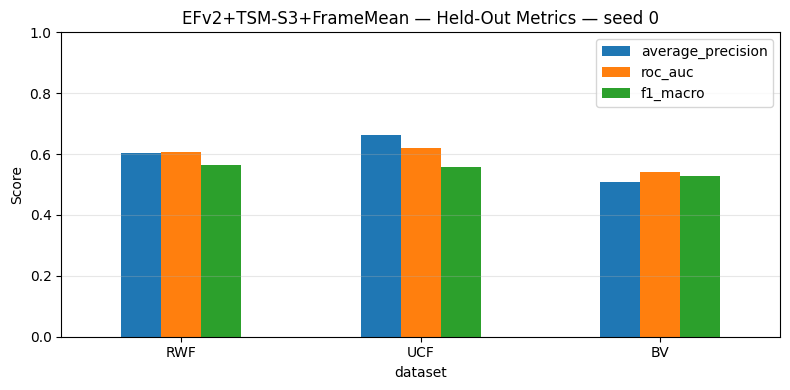

Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/HeldOut_Evaluation/EFv2_TSM_S3_FrameMean/seed_0/heldout_metrics_summary.png


In [12]:
results = []

ci_metric_names = [
    "accuracy",
    "f1_macro",
    "f1_violence",
    "roc_auc",
    "average_precision",
]

for dataset_position, (dataset_name, store) in enumerate(heldout_stores.items()):
    print("\n" + "=" * 90)
    print(
        f"EVALUATE {dataset_name} | EFv2+TSM-S3+FrameMean seed={RUN_SEED}"
    )
    print("=" * 90)

    dataset = HeldOutVideoDataset(
        store["feature_path"],
        store["label_path"],
        store["color_order"],
    )
    loader = make_loader(dataset)

    metrics, sample_indices, y_true, y_pred, probs = evaluate_loader(
        model, loader, DEVICE
    )

    output_dir = EVAL_OUTPUT_DIR / dataset_name
    output_dir.mkdir(parents=True, exist_ok=True)

    source_paths = load_paths_if_available(
        store.get("paths_path"), expected_n=len(dataset)
    )

    if source_paths is None:
        sample_keys = [
            f"{dataset_name}::{int(index)}" for index in sample_indices
        ]
        video_paths = ["" for _ in sample_indices]
    else:
        video_paths = [source_paths[int(index)] for index in sample_indices]
        sample_keys = [Path(path).as_posix() for path in video_paths]

    prediction_df = pd.DataFrame({
        "dataset": dataset_name,
        "variant": VARIANT,
        "seed": RUN_SEED,
        "sample_index": sample_indices,
        "sample_key": sample_keys,
        "video_path": video_paths,
        "y_true": y_true,
        "y_pred": y_pred,
        "is_correct": (y_true == y_pred).astype(np.int64),
        "p_nonviolence": probs[:, 0],
        "p_violence": probs[:, 1],
    })

    if prediction_df["sample_key"].duplicated().any():
        duplicated = prediction_df.loc[
            prediction_df["sample_key"].duplicated(), "sample_key"
        ].head(10).tolist()
        raise RuntimeError(
            f"Duplicate sample_key pada {dataset_name}: {duplicated}"
        )

    prediction_path = output_dir / "predictions.csv"
    prediction_df.to_csv(prediction_path, index=False)

    for metric_position, metric_name in enumerate(ci_metric_names):
        ci_seed = BOOTSTRAP_SEED + dataset_position * 100 + metric_position
        low, high = bootstrap_ci(
            y_true=y_true,
            y_pred=y_pred,
            p_violence=probs[:, 1],
            metric_name=metric_name,
            n_bootstrap=BOOTSTRAP_SAMPLES,
            seed=ci_seed,
        )
        metrics[f"{metric_name}_ci95_low"] = low
        metrics[f"{metric_name}_ci95_high"] = high

    metrics.update({
        "variant": VARIANT,
        "seed": RUN_SEED,
        "dataset": dataset_name,
        "checkpoint_path": str(CHECKPOINT_PATH),
        "best_epoch": checkpoint.get("epoch", np.nan),
        "best_val_f1_macro": checkpoint.get("best_score", np.nan),
        "cache_source": store["cache_source"],
    })
    results.append(metrics)

    save_plots(
        y_true=y_true,
        y_pred=y_pred,
        p_violence=probs[:, 1],
        title_prefix=f"EFv2+TSM-S3+FrameMean seed {RUN_SEED} — {dataset_name}",
        output_dir=output_dir,
    )

    print(
        f"N={metrics['n']} | "
        f"AP={metrics['average_precision']:.4f} | "
        f"AUC={metrics['roc_auc']:.4f} | "
        f"Macro-F1={metrics['f1_macro']:.4f}"
    )

    del dataset, loader, probs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

heldout_metrics_df = pd.DataFrame(results)
metrics_output = (
    EVAL_OUTPUT_DIR
    / f"heldout_metrics_efv2_tsm_s3_frame_mean_seed_{RUN_SEED}.csv"
)
heldout_metrics_df.to_csv(metrics_output, index=False)

display_columns = [
    "dataset", "n", "accuracy", "balanced_accuracy",
    "f1_macro", "precision_violence", "recall_violence",
    "f1_violence", "roc_auc", "average_precision",
]

print("\n=== HELD-OUT RESULTS ===")
display(heldout_metrics_df[display_columns].round(4))
print("Saved:", metrics_output)

# Ringkasan visual AP/AUC/Macro-F1 untuk tiga held-out domain.
plot_df = heldout_metrics_df.set_index("dataset")[[
    "average_precision", "roc_auc", "f1_macro"
]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title(f"EFv2+TSM-S3+FrameMean — Held-Out Metrics — seed {RUN_SEED}")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
summary_plot_path = EVAL_OUTPUT_DIR / "heldout_metrics_summary.png"
plt.savefig(summary_plot_path, dpi=180)
plt.show()
print("Saved:", summary_plot_path)


## 8. Simpan evaluation manifest

In [13]:
manifest = {
    "task": "heldout_evaluation_only",
    "training_performed": False,
    "variant": VARIANT,
    "checkpoint_seed": RUN_SEED,
    "checkpoint_path": str(CHECKPOINT_PATH),
    "checkpoint_epoch": checkpoint.get("epoch"),
    "checkpoint_best_val_f1_macro": checkpoint.get("best_score"),
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "sequence_length": SEQUENCE_LENGTH,
    "raw_resolution": [RAW_HEIGHT, RAW_WIDTH],
    "backbone_input_size": [BACKBONE_INPUT_SIZE, BACKBONE_INPUT_SIZE],
    "uses_tsm": True,
    "tsm_shift_div": TSM_SHIFT_DIV,
    "tsm_after_stage_indices": list(TSM_AFTER_STAGE_INDICES),
    "tsm_placement_name": TSM_PLACEMENT_NAME,
    "temporal_aggregation": "mean_of_tsm_mixed_frame_features",
    "uses_bilstm": False,
    "uses_temporal_attention": False,
    "normalization": "ImageNet",
    "use_amp": USE_AMP,
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "heldout_datasets": list(HELDOUT_SPECS.keys()),
    "checkpoint_config": checkpoint_config,
}

manifest_path = EVAL_OUTPUT_DIR / "evaluation_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, default=str)

print("Manifest:", manifest_path)
print("\n✅ EFv2+TSM-S3+FrameMean held-out evaluation selesai.")
print("✅ Tidak ada training/backpropagation pada notebook ini.")


Manifest: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/HeldOut_Evaluation/EFv2_TSM_S3_FrameMean/seed_0/evaluation_manifest.json

✅ EFv2+TSM-S3+FrameMean held-out evaluation selesai.
✅ Tidak ada training/backpropagation pada notebook ini.


## 9. Paket hasil

In [14]:
archive_base = str(
    EVAL_OUTPUT_DIR.parent / f"{EVAL_OUTPUT_DIR.name}_EFv2_TSM_S3_FrameMean_HeldOut"
)
archive_path = shutil.make_archive(
    archive_base, "zip", root_dir=EVAL_OUTPUT_DIR
)
print("Archive created:", archive_path)
print("Results folder :", EVAL_OUTPUT_DIR)


Archive created: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/HeldOut_Evaluation/EFv2_TSM_S3_FrameMean/seed_0_EFv2_TSM_S3_FrameMean_HeldOut.zip
Results folder : /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/HeldOut_Evaluation/EFv2_TSM_S3_FrameMean/seed_0


### Seed berikutnya
Ubah hanya `RUN_SEED` menjadi `42` atau `123`, lalu **Runtime → Restart session and run all**. Jangan mengubah preprocessing, cache, atau arsitektur.